# Build an LSTM Model Across Market and ETF Tickers

This notebook trains one pooled LSTM return-regression model using broad market ETFs, sector ETFs, bond ETFs, and commodity/real-asset ETFs. The goal is to test whether smoother market-level series are easier for the LSTM to predict than individual stocks.

yfinance uses Yahoo Finance symbols. ETF tickers are used for training because they include tradable OHLCV data. Raw market index symbols such as `^GSPC`, `^DJI`, and `^IXIC` are included in the availability check, but they are excluded from training by default because several index symbols have weak or missing volume data for our current features.

Reference sources used for the ticker set: [yfinance PyPI](https://pypi.org/project/yfinance/), [SPDR S&P 500 ETF Trust](https://en.wikipedia.org/wiki/SPDR_S%26P_500_ETF_Trust), [SPDR fund family](https://en.wikipedia.org/wiki/SPDR), [Invesco QQQ](https://www.investopedia.com/ask/answers/061715/what-qqq-etf.asp), and [Vanguard ETF examples](https://www.kiplinger.com/investing/etfs/best-vanguard-etfs).

In [1]:
# Run this install cell only when the notebook environment is missing packages.
# %pip install tensorflow scikit-learn matplotlib pandas yfinance ta


In [ ]:
# Keep the imports together so the notebook dependencies are easy to check.
import gc
import sys
from pathlib import Path

# Add the backend folder to the path so this notebook can reuse the shared project code.
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow import keras

# Use the same feature and LSTM helpers as the other notebooks.
from core.fetch_data import OHLCV_COLS, SELECTED_FEATURE_COLS, download_ticker, get_ticker_features
from core.lstm_helpers import (
    build_lstm_model,
    build_sector_data as build_lstm_dataset,
    inverse_scale_predictions,
    regression_metrics,
)


## 1. Configuration

In [3]:
# Start the raw feature download before the model period.
# This gives the moving averages enough warm-up data before 2022.
FEATURE_START = '2021-10-01'

# Keep the train, validation, and test periods separate by date.
# This makes the test period a clean final check on 2025 data.
TRAIN_START = '2022-01-01'
TRAIN_MODEL_END = '2023-12-31'
VALIDATION_START = '2024-01-01'
VALIDATION_END = '2024-12-31'
TEST_START = '2025-01-01'
TEST_END = '2025-12-31'

# Download past 2025 because a late-2025 row still needs 5 future trading days.
DOWNLOAD_END = '2026-01-10'

# Use a 30-day input window to predict the 5-trading-day return.
FORECAST_HORIZON = 5
WINDOW_SIZE = 30

# These settings control the model training loop.
MAX_EPOCHS = 30
BATCH_SIZE = 128
EARLY_STOPPING_PATIENCE = 5
RANDOM_SEED = 42

# Save the market/ETF model separately from the stock models.
MODEL_DIR = Path('../trained_models/lstm_market_etf_return_regression')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Use the shared feature list from fetch_data.py and remove duplicates defensively.
FEATURE_COLS = list(dict.fromkeys(SELECTED_FEATURE_COLS))


## 2. Market and ETF Ticker Universe

In [4]:
# These symbols use Yahoo Finance/yfinance ticker names.
# ETF symbols are used for training because they include tradable OHLCV data.
MARKET_ETF_GROUPS = {
    'Broad US equity ETFs': [
        'SPY',  # S&P 500
        'VOO',  # S&P 500
        'IVV',  # S&P 500
        'VTI',  # Total US stock market
        'QQQ',  # Nasdaq-100
        'DIA',  # Dow Jones Industrial Average
        'IWM',  # Russell 2000
        'MDY',  # S&P MidCap 400
    ],
    'International equity ETFs': [
        'VEA',  # Developed markets
        'EFA',  # EAFE developed markets
        'VXUS',  # Total international stock market
        'EEM',  # Emerging markets
        'VWO',  # Emerging markets
    ],
    'Bond ETFs': [
        'BND',  # Total bond market
        'AGG',  # Core US aggregate bonds
        'TLT',  # Long-term Treasuries
        'IEF',  # Intermediate Treasuries
        'SHY',  # Short-term Treasuries
        'LQD',  # Investment grade corporate bonds
        'HYG',  # High yield corporate bonds
    ],
    'Commodity and real asset ETFs': [
        'GLD',  # Gold
        'SLV',  # Silver
        'USO',  # Oil
        'VNQ',  # US real estate
    ],
    'Sector SPDR ETFs': [
        'XLK',  # Technology
        'XLC',  # Communication services
        'XLY',  # Consumer discretionary
        'XLP',  # Consumer staples
        'XLE',  # Energy
        'XLF',  # Financials
        'XLV',  # Health care
        'XLI',  # Industrials
        'XLB',  # Materials
        'XLRE',  # Real estate
        'XLU',  # Utilities
    ],
}

# Raw market index symbols can be downloaded by yfinance, but many do not have useful volume.
# They are checked for availability, but excluded from the model by default.
MARKET_INDEX_TICKERS = [
    '^GSPC',  # S&P 500 index
    '^DJI',  # Dow Jones Industrial Average
    '^IXIC',  # Nasdaq Composite
    '^RUT',  # Russell 2000
    '^VIX',  # CBOE Volatility Index
]

ETF_TICKERS = list(dict.fromkeys(
    ticker
    for tickers in MARKET_ETF_GROUPS.values()
    for ticker in tickers
))
TICKER_TO_GROUP = {
    ticker: group
    for group, tickers in MARKET_ETF_GROUPS.items()
    for ticker in tickers
}
TRAINING_TICKERS = ETF_TICKERS
ALL_CANDIDATE_TICKERS = list(dict.fromkeys(ETF_TICKERS + MARKET_INDEX_TICKERS))

print(f'{len(TRAINING_TICKERS)} ETF training tickers')
print(f'{len(MARKET_INDEX_TICKERS)} raw market index tickers available for checking')
print(f'{len(FEATURE_COLS)} features per day, {WINDOW_SIZE}-day sequences')
print(f'Forecast target: {FORECAST_HORIZON}-trading-day return')


35 ETF training tickers
5 raw market index tickers available for checking
18 features per day, 30-day sequences
Forecast target: 5-trading-day return


In [5]:
# Check which ETF and market symbols return usable Yahoo Finance data.
# This cell is useful because yfinance availability follows Yahoo Finance symbols.
availability_rows = []

for ticker in ALL_CANDIDATE_TICKERS:
    raw = pd.DataFrame()

    try:
        raw = download_ticker(ticker, start='2024-01-01', end='2024-03-01')
        has_ohlcv_cols = all(col in raw.columns for col in OHLCV_COLS)
        has_rows = len(raw) > 0
        has_volume = bool(has_ohlcv_cols and raw['Volume'].fillna(0).gt(0).any())
        use_for_training = ticker in TRAINING_TICKERS and has_rows and has_ohlcv_cols
        note = 'ETF training candidate' if ticker in TRAINING_TICKERS else 'raw market index check only'
    except Exception as error:
        has_rows = False
        has_ohlcv_cols = False
        has_volume = False
        use_for_training = False
        note = str(error)

    availability_rows.append({
        'ticker': ticker,
        'group': TICKER_TO_GROUP.get(ticker, 'Raw market index'),
        'rows': len(raw),
        'has_ohlcv_cols': has_ohlcv_cols,
        'has_nonzero_volume': has_volume,
        'use_for_training': use_for_training,
        'note': note,
    })

availability_df = pd.DataFrame(availability_rows)
availability_df


,ticker,group,rows,has_ohlcv_cols,has_nonzero_volume,use_for_training,note
0,SPY,Broad US equity ETFs,41,True,True,True,ETF training candidate
1,VOO,Broad US equity ETFs,41,True,True,True,ETF training candidate
2,IVV,Broad US equity ETFs,41,True,True,True,ETF training candidate
3,VTI,Broad US equity ETFs,41,True,True,True,ETF training candidate
4,QQQ,Broad US equity ETFs,41,True,True,True,ETF training candidate
5,DIA,Broad US equity ETFs,41,True,True,True,ETF training candidate
6,IWM,Broad US equity ETFs,41,True,True,True,ETF training candidate
7,MDY,Broad US equity ETFs,41,True,True,True,ETF training candidate
8,VEA,International equity ETFs,41,True,True,True,ETF training candidate
9,EFA,International equity ETFs,41,True,True,True,ETF training candidate


## 3. Load ETF Features

In [6]:
# Calculate the features once per ETF so the model uses one shared source dataset.
ticker_features = {}
skipped_tickers = []

for ticker in TRAINING_TICKERS:
    try:
        df = get_ticker_features(
            ticker=ticker,
            start=FEATURE_START,
            end=DOWNLOAD_END,
            smooth_outliers=True,
        )
    except Exception as error:
        skipped_tickers.append({'ticker': ticker, 'reason': str(error)})
        print(f'{ticker}: skipped ({error})')
        continue

    # Skip tickers that cannot create one complete sequence and one future target.
    required_rows = WINDOW_SIZE + FORECAST_HORIZON + 1
    if df.empty or len(df) < required_rows:
        skipped_tickers.append({'ticker': ticker, 'reason': f'only {len(df)} rows'})
        print(f'{ticker}: skipped (only {len(df)} rows)')
        continue

    ticker_features[ticker] = df
    print(f'{ticker}: {len(df)} rows ({df.index[0].date()} to {df.index[-1].date()})')

print(f'Loaded {len(ticker_features)} of {len(TRAINING_TICKERS)} ETF tickers.')

if skipped_tickers:
    display(pd.DataFrame(skipped_tickers))


SPY: 1024 rows (2021-12-10 to 2026-01-09)
VOO: 1024 rows (2021-12-10 to 2026-01-09)
IVV: 1024 rows (2021-12-10 to 2026-01-09)
VTI: 1024 rows (2021-12-10 to 2026-01-09)
QQQ: 1024 rows (2021-12-10 to 2026-01-09)
DIA: 1024 rows (2021-12-10 to 2026-01-09)
IWM: 1024 rows (2021-12-10 to 2026-01-09)
MDY: 1024 rows (2021-12-10 to 2026-01-09)
VEA: 1024 rows (2021-12-10 to 2026-01-09)
EFA: 1024 rows (2021-12-10 to 2026-01-09)
VXUS: 1024 rows (2021-12-10 to 2026-01-09)
EEM: 1024 rows (2021-12-10 to 2026-01-09)
VWO: 1024 rows (2021-12-10 to 2026-01-09)
BND: 1024 rows (2021-12-10 to 2026-01-09)
AGG: 1024 rows (2021-12-10 to 2026-01-09)
TLT: 1024 rows (2021-12-10 to 2026-01-09)
IEF: 1024 rows (2021-12-10 to 2026-01-09)
SHY: 1024 rows (2021-12-10 to 2026-01-09)
LQD: 1024 rows (2021-12-10 to 2026-01-09)
HYG: 1024 rows (2021-12-10 to 2026-01-09)
GLD: 1024 rows (2021-12-10 to 2026-01-09)
SLV: 1024 rows (2021-12-10 to 2026-01-09)
USO: 1024 rows (2021-12-10 to 2026-01-09)
VNQ: 1024 rows (2021-12-10 to 202

## 4. Build the Pooled ETF Dataset

In [7]:
# Build one pooled dataset using the ETF ticker universe.
dataset = build_lstm_dataset(
    TRAINING_TICKERS,
    ticker_features,
    FEATURE_COLS,
    TRAIN_START,
    TRAIN_MODEL_END,
    VALIDATION_START,
    VALIDATION_END,
    TEST_START,
    TEST_END,
    WINDOW_SIZE,
    FORECAST_HORIZON,
)

if dataset is None:
    raise ValueError('No valid ETF dataset could be built from the available tickers.')

print(f"Training samples: {len(dataset['train']['y'])}")
print(f"Validation samples: {len(dataset['validation']['y'])}")
print(f"Test samples: {len(dataset['test']['y'])}")
print(f"Tickers used: {len(dataset['tickers'])}")


Training samples: 16870
Validation samples: 8645
Test samples: 8750
Tickers used: 35


## 5. Train and Test the Market/ETF Model

In [8]:
# Train one model across the ETF universe.
X_train = dataset['train']['X']
y_train = dataset['train']['y_scaled']
X_validation = dataset['validation']['X']
y_validation = dataset['validation']['y_scaled']
X_test = dataset['test']['X']
y_test = dataset['test']['y']
current_close_test = dataset['test']['current_close']
target_close_test = dataset['test']['target_close']

# Reset the model state so this run is independent of earlier notebook runs.
keras.backend.clear_session()
keras.utils.set_random_seed(RANDOM_SEED)

model = build_lstm_model((WINDOW_SIZE, len(FEATURE_COLS)))

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_mae',
    mode='min',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

# Validation data controls early stopping. The test data is only used after training.
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=0,
)

# Convert scaled return predictions back before calculating price metrics.
y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).flatten()
y_pred = inverse_scale_predictions(dataset['target_scaler'], y_pred_scaled)
naive_pred = np.zeros_like(y_test)

model_metrics = regression_metrics(y_pred, current_close_test, target_close_test)
naive_metrics = regression_metrics(naive_pred, current_close_test, target_close_test)

model_path = MODEL_DIR / f'market_etfs_{FORECAST_HORIZON}d_return.keras'
model.save(model_path)

# A positive difference means the pooled ETF LSTM beat the zero-return baseline.
result = {
    'model': 'Market and ETF LSTM',
    'forecast_horizon': f'{FORECAST_HORIZON}d',
    'tickers': len(dataset['tickers']),
    'train_samples': len(dataset['train']['y']),
    'validation_samples': len(dataset['validation']['y']),
    'test_samples': len(y_test),
    'naive_mae': naive_metrics['mae'],
    'mae': model_metrics['mae'],
    'mae_difference': naive_metrics['mae'] - model_metrics['mae'],
    'naive_rmse': naive_metrics['rmse'],
    'rmse': model_metrics['rmse'],
    'rmse_difference': naive_metrics['rmse'] - model_metrics['rmse'],
    'naive_mape': naive_metrics['mape'],
    'mape': model_metrics['mape'],
    'mape_difference': naive_metrics['mape'] - model_metrics['mape'],
    'epochs': len(history.history['loss']),
    'model_path': str(model_path),
}
result['beats_naive'] = result['mae_difference'] > 0

results_df = pd.DataFrame([result])
metric_cols = [
    'naive_mae',
    'mae',
    'mae_difference',
    'naive_rmse',
    'rmse',
    'rmse_difference',
    'naive_mape',
    'mape',
    'mape_difference',
]
results_df[metric_cols] = results_df[metric_cols].round(4)

artifact = {
    'metadata': dataset['test']['metadata'],
    'y_test': y_test,
    'y_pred': y_pred,
    'current_close': current_close_test,
    'target_close': target_close_test,
}

display(results_df)

del model
gc.collect()


,model,forecast_horizon,tickers,train_samples,validation_samples,test_samples,naive_mae,mae,mae_difference,naive_rmse,rmse,rmse_difference,naive_mape,mape,mape_difference,epochs,model_path,beats_naive
0,Market and ETF LSTM,5d,35,16870,8645,8750,3.0173,3.2591,-0.2418,6.0151,6.2024,-0.1873,0.0165,0.0184,-0.0019,6,../trained_models/lstm_market_etf_return_regre...,False


1280

## 6. Build Prediction Rows

In [9]:
# Build a prediction table that can be grouped by ETF type or ticker.
prediction_rows = artifact['metadata'].copy()
prediction_rows['group'] = prediction_rows['ticker'].map(TICKER_TO_GROUP)
prediction_rows['actual_return'] = artifact['y_test']
prediction_rows['predicted_return'] = artifact['y_pred']
prediction_rows['current_close'] = artifact['current_close']
prediction_rows['actual_close'] = artifact['target_close']
prediction_rows['predicted_close'] = (
    prediction_rows['current_close'] * (1 + prediction_rows['predicted_return'])
)

prediction_rows.head()


,ticker,prediction_date,target_date,group,actual_return,predicted_return,current_close,actual_close,predicted_close
0,SPY,2025-01-02,2025-01-10,Broad US equity ETFs,-0.007098,-0.000702,574.799500,570.719299,574.395935
1,SPY,2025-01-03,2025-01-13,Broad US equity ETFs,-0.017839,-0.000800,581.986450,571.604248,581.520874
2,SPY,2025-01-06,2025-01-14,Broad US equity ETFs,-0.022121,-0.000956,585.339111,572.390686,584.779724
3,SPY,2025-01-07,2025-01-15,Broad US equity ETFs,0.007050,-0.001068,578.722412,582.802490,578.104187
4,SPY,2025-01-08,2025-01-16,Broad US equity ETFs,0.003647,-0.001123,579.567871,581.681702,578.916870


In [ ]:
def summarize_prediction_group(rows, group_col):
    summaries = []

    for group_name, group in rows.groupby(group_col):
        group_y_pred = group['predicted_return'].to_numpy()
        group_naive_pred = np.zeros(len(group), dtype=np.float32)
        group_current_close = group['current_close'].to_numpy()
        group_target_close = group['actual_close'].to_numpy()

        group_model_metrics = regression_metrics(
            group_y_pred,
            group_current_close,
            group_target_close,
        )
        group_naive_metrics = regression_metrics(
            group_naive_pred,
            group_current_close,
            group_target_close,
        )

        summaries.append({
            group_col: group_name,
            'samples': len(group),
            'naive_mae': group_naive_metrics['mae'],
            'mae': group_model_metrics['mae'],
            'mae_difference': group_naive_metrics['mae'] - group_model_metrics['mae'],
            'naive_rmse': group_naive_metrics['rmse'],
            'rmse': group_model_metrics['rmse'],
            'rmse_difference': group_naive_metrics['rmse'] - group_model_metrics['rmse'],
            'naive_mape': group_naive_metrics['mape'],
            'mape': group_model_metrics['mape'],
            'mape_difference': group_naive_metrics['mape'] - group_model_metrics['mape'],
        })

    summary_df = pd.DataFrame(summaries)
    summary_metric_cols = [
        'naive_mae',
        'mae',
        'mae_difference',
        'naive_rmse',
        'rmse',
        'rmse_difference',
        'naive_mape',
        'mape',
        'mape_difference',
    ]
    summary_df[summary_metric_cols] = summary_df[summary_metric_cols].round(4)

    return summary_df.sort_values('mae_difference', ascending=False)


## 7. Compare Results by ETF Group

In [11]:
# ETF group-level results show whether the model works better on slower-moving asset classes.
group_results_df = summarize_prediction_group(prediction_rows, 'group')
group_results_df


,group,samples,naive_mae,mae,mae_difference,naive_rmse,rmse,rmse_difference,naive_mape,mape,mape_difference
4,Sector SPDR ETFs,2750,1.5809,1.6869,-0.1060,2.3572,2.4561,-0.0989,0.0190,0.0202,-0.0013
2,Commodity and real asset ETFs,1000,2.9586,3.1526,-0.1941,5.0119,5.2545,-0.2426,0.0244,0.0256,-0.0011
0,Bond ETFs,1750,0.5036,0.7404,-0.2367,0.7541,0.9573,-0.2032,0.0058,0.0086,-0.0028
3,International equity ETFs,1250,1.0025,1.2557,-0.2532,1.3664,1.5903,-0.2239,0.0171,0.0213,-0.0042
1,Broad US equity ETFs,2000,8.4805,8.9302,-0.4497,11.6803,11.9927,-0.3124,0.0184,0.0193,-0.0009


## 8. Compare Results by Ticker

In [12]:
# Ticker-level results show which market proxies benefit most from the pooled model.
ticker_results_df = summarize_prediction_group(prediction_rows, 'ticker')
ticker_results_df


,ticker,samples,naive_mae,mae,mae_difference,naive_rmse,rmse,rmse_difference,naive_mape,mape,mape_difference
15,SPY,250,10.0639,9.8118,0.2520,13.4877,13.2718,0.2159,0.0170,0.0166,0.0004
26,XLE,250,1.0431,1.0159,0.0271,1.4740,1.4897,-0.0157,0.0249,0.0244,0.0006
32,XLU,250,0.6151,0.6264,-0.0112,0.7848,0.7983,-0.0135,0.0154,0.0157,-0.0003
17,USO,250,2.3462,2.3577,-0.0115,3.2418,3.2456,-0.0038,0.0323,0.0324,-0.0001
14,SLV,250,1.0578,1.0715,-0.0137,1.5689,1.5471,0.0217,0.0289,0.0290,-0.0002
12,QQQ,250,11.5853,11.6285,-0.0433,14.9279,14.9007,0.0272,0.0220,0.0220,-0.0001
6,HYG,250,0.3474,0.3951,-0.0478,0.4911,0.5281,-0.0369,0.0046,0.0053,-0.0006
30,XLP,250,1.0299,1.0869,-0.0570,1.3368,1.4016,-0.0648,0.0133,0.0140,-0.0007
10,LQD,250,0.6971,0.7690,-0.0719,0.9077,0.9863,-0.0786,0.0067,0.0074,-0.0007
27,XLF,250,0.9119,1.0112,-0.0993,1.2365,1.3167,-0.0802,0.0184,0.0203,-0.0019


## 9. Plot One ETF Prediction

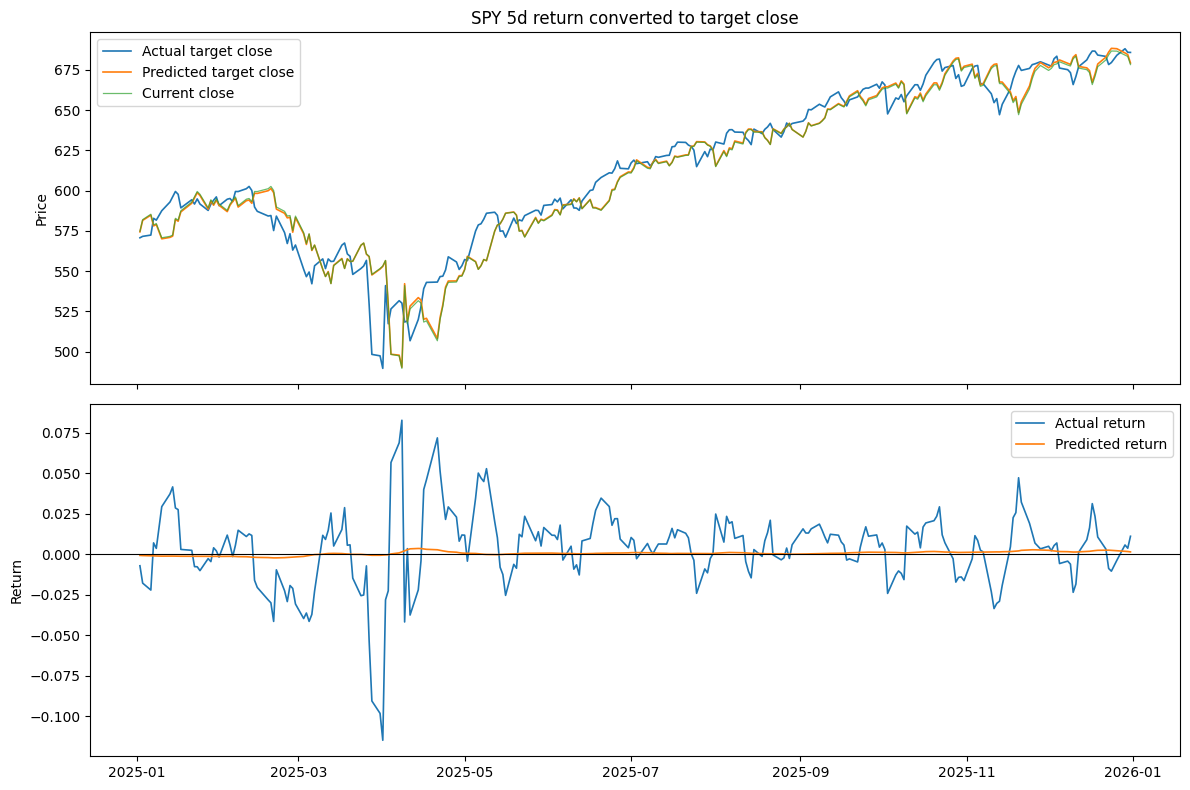

In [ ]:
# Plot one ETF prediction to see whether the model is lagging the actual price.
PLOT_TICKER = 'SPY'

if PLOT_TICKER not in set(prediction_rows['ticker']):
    PLOT_TICKER = prediction_rows['ticker'].iloc[0]

plot_rows = prediction_rows[prediction_rows['ticker'] == PLOT_TICKER].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(plot_rows['prediction_date'], plot_rows['actual_close'], label='Actual target close', linewidth=1.2)
axes[0].plot(plot_rows['prediction_date'], plot_rows['predicted_close'], label='Predicted target close', linewidth=1.2)
axes[0].plot(plot_rows['prediction_date'], plot_rows['current_close'], label='Current close', linewidth=0.9, alpha=0.7)
axes[0].set_title(f'{PLOT_TICKER} {FORECAST_HORIZON}d return converted to target close')
axes[0].set_ylabel('Price')
axes[0].legend()

# The return chart shows whether prediction errors come from direction or size.
axes[1].plot(plot_rows['prediction_date'], plot_rows['actual_return'], label='Actual return', linewidth=1.2)
axes[1].plot(plot_rows['prediction_date'], plot_rows['predicted_return'], label='Predicted return', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Return')
axes[1].legend()

plt.tight_layout()
plt.show()
